Author Lingting Shi, from Elham Azizi lab
Functions of this notebook is written by Zicheng Wang from Yufeng Shen lab from https://github.com/princello/TCRB_matching

In [4]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import seaborn as sns
import os
import matplotlib.pyplot as plt
from pathlib import Path

## Data pre-processing

### Read 10x and adaptive tcr sequencing data

---

**10x TCR Data (`tenx_data`)**:
- **Origin**: This dataset comes from 10X TCR sequencing (all_contig_annotations.csv).
- **Mandatory Columns**:
  - **barcode**: Unique identifier for each single cell.
  - **chain**: The specific T cell receptor chain being analyzed.
  - **cdr3**: The amino acid sequence of the CDR3 region.
  - **cdr3_nt**: The nucleotide sequence of the CDR3 region.
  - **v_gene** (also known as TCR V gene name): Represents the variable gene segment of the T cell receptor. It's a part of the TCR's genetic makeup.
  - **j_gene**: Represents the joining gene segment of the T cell receptor.
  - **raw_consensus_id**: A unique identifier for the consensus sequence.

**Note**: Different versions of the sequencing data might have alternative column names. Always refer to the latest documentation or data specification to ensure compatibility.

---

**Adaptive TRB Data (`adap_data`)**:
- **Origin**: This dataset comes from Adaptive TRB sequencing.
- **Mandatory Columns**:
  - **v_resolved**: Represents the resolved variable gene segment of the T cell receptor, analogous to the `v_gene` in the TCR data.
  - **j_resolved**: Represents the resolved joining gene segment of the T cell receptor.
  - **rearrangement**: The nucleotide (nt) sequence representing the rearranged T cell receptor gene.
  - **amino_acid**: Represents the amino acid sequence of the CDR3 region, a crucial part of the TCR that interacts with antigens.
  - **productive_frequency**: Frequency of productive T cell receptors with the given rearrangement.

**Note**: As with the TCR data, different versions of the Adaptive TRB sequencing data might have alternative column names. Users should always refer to the latest documentation or data specification to ensure proper understanding and compatibility.

---

In [5]:
PROJECT_ROOT = Path('../..')

# Input paths
META_PATH                     = PROJECT_ROOT / 'GVHD_Reproducibility-main' / 'scRNAseq_TCR_samples_meta_LS-15_f.xlsx'
TCR_DATA_DIR                  = PROJECT_ROOT / 'filtered_contig_annotations'
MLR_DATA_DIR                  = PROJECT_ROOT / 'Annotated_v4_PTCY'


# Output paths
TENX_DATA_PATH                = PROJECT_ROOT / 'adata_file' / 'tenx_data.csv'
ADAP_DATA_PATH                = PROJECT_ROOT / 'adata_file' / 'adap_data.csv'
TENX_DATA_SHARED_PATH         = PROJECT_ROOT / 'adata_file' / 'tenx_data_shared.csv'
ADAP_DATA_SHARED_PATH         = PROJECT_ROOT / 'adata_file' / 'adap_data_shared.csv'
TCR_SEL_ALL_PATH              = PROJECT_ROOT / 'adata_file' / 'tcr_sel_all.csv'

shared_patients = ['C068', 'C101', 'C98', 'C66', 'C86', 'C160', 'C179', 'C155']

In [6]:
# You can update your data location in the meta file
meta_df = pd.read_excel(META_PATH)
meta_df.index = meta_df['Sample ID']

In [7]:
meta_df

,Patient ID,Sample ID,submission,Alternative Patient ID,local_scRNAseq,Biopsy Date,Days post-Transplant,Tissue Location,Cell Type,Enrichment Method,...,GVHD Prophylaxis Regimen,Transplant Conditioning,Biological Sex,DoT,Time_1stGVHD,Donor_type,Disease,Shared_MLR,Dates_from_Transplantation,Doublet_rate
Sample ID,,,,,,,,,,,,,,,,,,,,,
R094_Tc18low,R094,R094_Tc18low,NaN,"C094, TC18",Missing (See Notes),NaT,NaN,Lower GI,Lamina Propria Cells,TCRab Enriched,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,0.06
R096_Tc17_low,R096,R096_Tc17_low,Fresh,"C96, TC17",/Users/lingting/Documents/GVHD_project/data/r0...,2018-10-10,27.0,Lower GI,Lamina Propria Cells,TCRab Enriched,...,Tac/Methotrexate,TBI/Cy,Male,2018-09-13,27.0,Matched Unrelated Donor,NK-T Cell Lymphoma,0.0,0.0,0.06
R096_Tc17_up,R096,R096_Tc17_up,Fresh,"C96, TC17",/Users/lingting/Documents/GVHD_project/data/r0...,2018-10-10,27.0,Upper GI,Lamina Propria Cells,TCRab Enriched,...,Tac/Methotrexate,TBI/Cy,Male,2018-09-13,27.0,Matched Unrelated Donor,NK-T Cell Lymphoma,0.0,0.0,0.06
RH01,C155,RH01,Fresh,NaN,/Users/lingting/Documents/GVHD_project/data/RH...,2021-08-26,27.0,Upper GI,Lamina Propria Cells,CD45+ Enriched,...,Tac/Mycophenolate/PTCy,Flu/TBI,Male,2021-07-30,129.0,Haplo,AML,0.0,-102.0,0.06
RH02,C155,RH02,Fresh,NaN,/Users/lingting/Documents/GVHD_project/data/RH...,2021-08-26,27.0,Upper GI,Intraepithelial Cells,CD45+ Enriched,...,Tac/Mycophenolate/PTCy,Flu/TBI,Male,2021-07-30,129.0,Haplo,AML,0.0,-102.0,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Update the sample list here need to be the same as sample ID
Sample_list = ["R096_Tc17_up","R096_Tc17_low","RH01","RH02","RH03","RH04","RH05","RH06","RH07","RH08","RH09","RH10","RH11","RH12","RH13","RH14","UA01","UA02","UA03","UA04","UA05","UA06","UA07","UA08","UA09","UA10","UA11","UA12",'UA13','UA14','UA15','UA19','UA20','UA21','UA22','UA23','UA24','UA26','UA30','UA31','UA32','UA33','UA34','UA35','UA36','UA37','UA38','UA39','UA40','UA41']

In [9]:
#Load in all 10x data
# if the TENX_DATA_PATH file already exists, you can directly load it in instead of running the code below to save time
if os.path.exists(TENX_DATA_PATH):
    tenx_data = pd.read_csv(TENX_DATA_PATH)
else:
    tenx_data= pd.DataFrame()
    for i in range(len(Sample_list)):
        sample_data = pd.read_csv(TCR_DATA_DIR / (Sample_list[i]+"_contig.csv"))
        sample_data['PatientID'] = np.repeat(meta_df.loc[Sample_list[i],'Patient ID'],sample_data.shape[0])
        sample_data['SampleID'] = np.repeat(meta_df.loc[Sample_list[i],'Sample ID'],sample_data.shape[0])
        sample_data['PatientID'] = np.repeat(meta_df.loc[Sample_list[i],'Patient ID'],sample_data.shape[0])
        sample_data['LPorIE'] = np.repeat(meta_df.loc[Sample_list[i],'Cell Type'],sample_data.shape[0])
        sample_data['Dates_from_Transplantation'] = np.repeat(meta_df.loc[Sample_list[i],'Dates_from_Transplantation'],sample_data.shape[0])
        sample_data['FreshorFrozen'] = np.repeat(meta_df.loc[Sample_list[i],'submission'],sample_data.shape[0])
        sample_data['Days_post-Transplant'] = np.repeat(meta_df.loc[Sample_list[i],'Days post-Transplant'],sample_data.shape[0])
        sample_data['Tissue_Location'] = np.repeat(meta_df.loc[Sample_list[i],'Tissue Location'],sample_data.shape[0])
        sample_data['Enrichment Method'] = np.repeat(meta_df.loc[Sample_list[i],'Enrichment Method'],sample_data.shape[0])
        sample_data['GVHD_Grade_1'] = np.repeat(meta_df.loc[Sample_list[i],'GVHD Grade_1'],sample_data.shape[0])
        sample_data['Time_1stGVHD'] = np.repeat(meta_df.loc[Sample_list[i],'Time_1stGVHD'],sample_data.shape[0])
        sample_data['Donor'] = np.repeat(meta_df.loc[Sample_list[i],'Donor_type'],sample_data.shape[0])
        sample_data['Disease'] = np.repeat(meta_df.loc[Sample_list[i],'Disease'],sample_data.shape[0])
        tenx_data = pd.concat([tenx_data,sample_data], ignore_index=True)
    tenx_data.to_csv(TENX_DATA_PATH, index=False)

In [10]:
#Load in adpative data
folder_names = os.listdir(MLR_DATA_DIR)
filtered_folder = [item for item in folder_names if 'Patient' in item]
filtered_folder

['Patient_098',
 'Patient_091',
 'Patient_090',
 'Patient_181',
 'Patient_143',
 'Patient_150',
 'Patient_160',
 'Patient_070',
 'Patient_076',
 'Patient_068',
 'Patient_066',
 'Patient_093',
 'Patient_067',
 'Patient_069',
 'Patient_051',
 'Patient_179',
 'Patient_183',
 'Patient_176',
 'Patient_153',
 'Patient_154',
 'Patient_137',
 'Patient_101',
 'Patient_155',
 'Patient_081',
 'Patient_086']

In [11]:
# if the ADAP_DATA_PATH file already exists, you can directly load it in instead of running the code below to save time
if os.path.exists(ADAP_DATA_PATH):
    adap_data = pd.read_csv(ADAP_DATA_PATH)
else:
    adap_data = pd.DataFrame()
    for folder in filtered_folder:
        folder_names = os.listdir(str(MLR_DATA_DIR)+'/'+folder+'/')
        filtered_files = [item for item in folder_names if 'tsv' in item]
        print(filtered_files)
        adap_sample = pd.concat([pd.read_csv(str(MLR_DATA_DIR)+'/'+folder+'/' + '/'+file, sep='\t') for file in filtered_files], ignore_index=True)
        clean_sample_name = []
        for file in filtered_files:
            clean_sample_name.extend(list(np.repeat(file,pd.read_csv(str(MLR_DATA_DIR)+'/'+folder+'/' +file, sep='\t').shape[0])))
        adap_sample['clean_sample_name'] = clean_sample_name
        adap_data = pd.concat([adap_data,adap_sample], ignore_index=True)
    split_df = adap_data['clean_sample_name'].str.split('_', expand=True)
    new_column_names = ['patientID', 'timepoints', 'sampletype']
    split_df.columns = new_column_names
    adap_data = pd.concat([adap_data, split_df], axis=1)
    adap_data.to_csv(ADAP_DATA_PATH, index=False)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_4464/2869681743.py:3: DtypeWarning: Columns (0,1,3,5,6,7,9,41,42,43,46,48,62,81,82,83,88,89,92,93,99,100,101,104,105,112,115,116,120) have mixed types. Specify dtype option on import or set low_memory=False.
  adap_data = pd.read_csv(ADAP_DATA_PATH)


In [12]:
adap_data['clean_sample_name'].value_counts().head(10)

clean_sample_name
R091_730_both.tsv            409744
R051_730_both.tsv            309242
R150_unstimulated_CD3.tsv    276623
R179_unstimulated_CD3.tsv    253234
R179_3_both.tsv              237342
R150_180_both.tsv            230919
R098_unstimulated_CD4.tsv    230797
R066_unstimulated_CD4.tsv    220367
R150_113_both.tsv            173881
R150_56_both.tsv             172015
Name: count, dtype: int64

## Data processing

### Linking 10X TCR Sequencing Data with Adaptive TRB Sequencing Data

The objective of this data processing is to establish a connection between the information provided by 10X TCR sequencing data and Adaptive TRB sequencing data, emphasizing the relevant features of T-cell receptors (TCR). To achieve this, the code is structured into three main functions, each with a specific purpose:

1. **`treatcr(tenx_data)`**:
    - This function processes the 10X TCR sequencing data.
    - Filters the data to focus on T-cell receptors with the 'TRB' chain that have identifiable V and J gene segments.
    - Further categorizes the V and J regions for better analysis.
    - Counts the occurrences of each TCR clonotype, indicating clonal expansion which can be crucial for understanding immune responses.

2. **`treathvg(adap_data, sample_name='', labeled_trb=[])`**:
    - This function deals with the Adaptive TRB sequencing data.
    - Depending on provided parameters, it can focus on specific samples or labeled TCR sequences.
    - It ensures the V and J regions of the TCR are resolved (i.e., identifiable).
    - Similar to `treatcr`, it further categorizes the V and J regions for nuanced analysis.

3. **`link(tcr_data, hvg_data, level=1)`**:
    - This function links the processed data from both the above functions.
    - The linking can be done at different levels based on V and J regions. 
    - At level 1, it considers the V and J gene families, while at level 2, it takes into account the subtypes as well.
    - The output is a filtered TCR dataset that matches with the Adaptive TRB sequences based on the linking criteria.

Lastly, the main workflow combines the functionality of the three functions to deliver a consolidated result:
1. It processes the 10X TCR sequencing data.
2. Processes the Adaptive TRB sequencing data by focusing on specific samples and labeled TRB sequences.
3. Establishes a link between the two processed datasets, resulting in the final output: `tcr_sel`.

In essence, the provided code enables a detailed comparison and integration of 10X TCR sequencing data with Adaptive TRB sequencing data, highlighting relevant T-cell receptor sequences and their properties.

--- 

In [13]:
def treatcr(tenx_data):
    # 1. Filter out data rows based on specific conditions.
    #    - We're specifically interested in T cell receptors with the 'TRB' chain. 
    #    - We also ensure that the V and J regions have been identified and that there's a consensus ID.
    #    Making a copy of the filtered DataFrame avoids any potential issues with modifying the original data.
    tcr_data = tenx_data[
        (tenx_data['chain'] == 'TRB') & 
        (tenx_data['v_gene'] != 'None') & 
        (tenx_data['j_gene'] != 'None') & 
        (tenx_data['raw_consensus_id'] != 'None')
    ].copy()

    # 2. Split the 'v_gene' and 'j_gene' columns by '-'
    #    The V (Variable) and J (Joining) regions in the TCR sequences often have a format like 'TRBV6-4'.
    #    Here, we're separating out the main family (e.g., 'TRBV6') from the specific subtype (e.g., '4').
    tcr_data['V_split'] = tcr_data['v_gene'].str.split('-')
    tcr_data['J_split'] = tcr_data['j_gene'].str.split('-')
    
    # 3. Extract relevant sub-strings from the split columns to derive 'V1', 'V2', 'J1', and 'J2' columns
    #    This helps in further categorizing and analyzing the V and J regions separately.
    tcr_data['V1'] = tcr_data['V_split'].str[0].str[4:].str.zfill(2)  # Extract the V family
    tcr_data['V2'] = tcr_data['V_split'].str[1].str.zfill(2).fillna('01')  # Extract the V subtype
    tcr_data['J1'] = tcr_data['J_split'].str[0].str[4:].str.zfill(2)  # Similar extraction for the J region
    tcr_data['J2'] = tcr_data['J_split'].str[1].str.zfill(2).fillna('01')
    
    # 4. Drop the temporary columns that were used for splitting.
    tcr_data.drop(columns=['V_split', 'J_split'], inplace=True)

    # 5. Count occurrences of each 'raw_clonotype_id' and map those counts to a new column '#clones'
    #    This gives us an idea of the clonal expansion of each TCR, which can be indicative of an immune response.
    tcr_data['#clones'] = tcr_data['raw_clonotype_id'].map(tcr_data['raw_clonotype_id'].value_counts())
    
    # 6. Return the desired columns in the specified order.
    #    These columns contain relevant information for further TCR analysis.
    return tcr_data[['barcode','SampleID_barcode', 'raw_clonotype_id', 'cdr3', 'cdr3_nt', '#clones', 'V1', 'V2', 'J1', 'J2']]


In [14]:
def treathvg(adap_data, sample_name='', labeled_trb=[]):
    """
    Process and extract relevant information from adaptive TRB sequencing data.
    
    Parameters:
    - adap_data: DataFrame containing the adaptive TRB sequencing data
    - sample_name: Name of the sample to be filtered (if specified)
    - labeled_trb: List of labeled CDR3 nucleotide sequences
    
    Returns:
    DataFrame with columns ['rearrangement','amino_acid','V1','V2','J1','J2','productive_frequency']
    """
    
    # If no sample name or labeled data is provided, filter out rows where V and J gene annotations are unresolved.
    # Otherwise, further filter based on sample name and labeled TRB sequences.
    if not sample_name and not labeled_trb:
        hvg_data = adap_data[
            (adap_data['v_resolved'].str[:2] != 'un') & 
            (adap_data['j_resolved'].str[:2] != 'un') 
        ].copy()
    
    elif not sample_name:
        hvg_data = adap_data[
            (adap_data['v_resolved'].str[:2] != 'un') & 
            (adap_data['j_resolved'].str[:2] != 'un') &
            (adap_data['rearrangement'].isin(labeled_trb))
        ].copy()
    elif not labeled_trb:
        adap_data = adap_data[adap_data['sample_name'] == sample_name].copy()
        hvg_data = adap_data[
            (adap_data['v_resolved'].str[:2] != 'un') & 
            (adap_data['j_resolved'].str[:2] != 'un')
        ] 
    else:
        adap_data = adap_data[adap_data['sample_name'] == sample_name].copy()
        hvg_data = adap_data[
            (adap_data['v_resolved'].str[:2] != 'un') & 
            (adap_data['j_resolved'].str[:2] != 'un') & 
            (adap_data['rearrangement'].isin(labeled_trb))
        ] 

    # Remove duplicate rows based on 'rearrangement' to get unique sequences.
    hvg_data = hvg_data.drop_duplicates(subset='rearrangement', keep='first')

    # Extract the V and J gene families and subtypes for further analysis.
    hvg_data['V_split'] = hvg_data['v_resolved'].str.split('-')
    hvg_data['J_split'] = hvg_data['j_resolved'].str.split('-')
    
    hvg_data['V1'] = hvg_data['V_split'].str[0].str[5:]
    hvg_data['V2'] = hvg_data['V_split'].str[1].str[:2].fillna('01')
    hvg_data['J1'] = hvg_data['J_split'].str[0].str[5:]
    hvg_data['J2'] = hvg_data['J_split'].str[1].str[:2].fillna('01')
    
    # Drop the temporary columns used for splitting.
    hvg_data.drop(columns=['V_split', 'J_split'], inplace=True)

    # Return the desired columns with important TCR information.
    return hvg_data[['rearrangement', 'amino_acid', 'V1', 'V2', 'J1', 'J2', 'productive_frequency']]


In [15]:
def link(tcr_data, hvg_data, level=1):
    """
    Links the outputs of treatcr and treathvg functions based on the given criteria.
    
    Parameters:
    ----------
    tcr_data : pd.DataFrame
        The DataFrame from the treatcr function output.
    hvg_data : pd.DataFrame
        The DataFrame from the treathvg function output.
    level : int, optional (default=1)
        Determines the linking criteria.
        If 1, links based on 'V1' and 'J1';
        if 2, uses 'V1', 'V2', 'J1', and 'J2'.
    
    Returns:
    --------
    pd.DataFrame
        Represents linked data from treatcr and treathvg outputs.
    """
    
    indexs = []
    ans = []

    for index, row in tcr_data.iterrows():
        # Filter out records that have the row['cdr3_nt'] sequence in them.
        matched_records = hvg_data[hvg_data['rearrangement'].str.contains(row['cdr3_nt'], na=False, regex=False)]
        
        ans_temp = []
        
        for _, rec in matched_records.iterrows():
            # Determine match criteria based on the level argument.
            is_match = False
            if level == 1:
                is_match = rec['V1'] == row['V1'] and rec['J1'] == row['J1']
            elif level == 2:
                is_match = (rec['V1'] == row['V1'] and rec['V2'] == row['V2'] and
                            rec['J1'] == row['J1'] and rec['J2'] == row['J2'])
            
            if is_match:
                indexs.append(index)
                ans_temp.append(rec['rearrangement'])
                
        if ans_temp:
            ans.append(ans_temp)

    ans_list = ['; '.join(temp) for temp in ans]
    indexs = sorted(set(indexs))
    tcr_sel = tcr_data.loc[indexs]
    tcr_sel['Adaptive NT sequences'] = ans_list
    

    return tcr_sel


In [16]:
adap_data['patientID'].unique()

array(['R098', 'R091', 'R090', 'R181', 'R143', 'R150', 'R160', 'R070',
       'R076', 'R068', 'R066', 'R093', 'R067', 'R069', 'R051', 'R179',
       'R183', 'R176', 'R153', 'R154', 'R137'], dtype=object)

In [17]:
replacement_dict = {'R068': 'C068', 'R101': 'C101','R098': 'C98', 'R091': 'C91','R066': 'C66', 'R086': 'C86','R160': 'C160', 'R179': 'C179', 'R155': 'C155'}
adap_data['patientID'] = adap_data['patientID'].replace(replacement_dict)

In [18]:
tenx_data= tenx_data[tenx_data['PatientID'].isin(shared_patients)]

In [19]:
tenx_data

,barcode,is_cell,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,...,cdr1_nt,fwr2,fwr2_nt,cdr2,cdr2_nt,fwr3,fwr3_nt,fwr4,fwr4_nt,exact_subclonotype_id
7800,AAACCTGGTTCACCTC-1,True,AAACCTGGTTCACCTC-1_contig_1,True,465,TRA,TRAV13-1,NaN,TRAJ13,TRAC,...,GACAGTGCCTCAAACTAC,FPWYKQELGKRPQLIID,TTCCCTTGGTATAAGCAAGAACTTGGAAAAAGACCTCAGCTTATTA...,IRSNVGE,ATTCGTTCAAATGTGGGCGAA,KKDQRIAVTLNKTAKHFSLHITETQPEDSAVYF,AAGAAAGACCAACGAATTGCTGTTACATTGAACAAGACAGCCAAAC...,GTGTKLQVIP,GGAACTGGAACAAAGCTCCAAGTCATCCCAA,1.0
7801,AAACCTGGTTCACCTC-1,True,AAACCTGGTTCACCTC-1_contig_2,True,512,TRB,TRBV6-1,TRBD1,TRBJ1-2,TRBC1,...,ATGAACCATAACTCC,MYWYRQDPGMGLRLIYY,ATGTACTGGTATCGACAAGACCCAGGCATGGGACTGAGGCTGATTT...,SASEGT,TCAGCTTCTGAGGGTACC,TDKGEVPNGYNVSRLNKREFSLRLESAAPSQTSVYF,ACTGACAAAGGAGAAGTCCCCAATGGCTACAATGTCTCCAGATTAA...,GSGTRLTVV,GGTTCGGGGACCAGGTTAACCGTTGTAG,1.0
7802,AAACCTGGTTCAGTAC-1,True,AAACCTGGTTCAGTAC-1_contig_1,True,475,TRA,TRAV10,NaN,TRAJ20,TRAC,...,GTGAGCCCCTTCAGCAAC,LRWYKQDTGRGPVSLTI,TTAAGGTGGTATAAGCAAGATACTGGGAGAGGTCCTGTTTCCCTGA...,MTFSENT,ATGACTTTCAGTGAGAACACA,KSNGRYTATLDADTKQSSLHITASQLSDSASYI,AAGTCGAACGGAAGATATACAGCAACTCTGGATGCAGACACAAAGC...,GAGTTVTVRA,GGAGCCGGAACCACAGTAACTGTAAGAGCAA,1.0
7803,AAACCTGGTTCAGTAC-1,True,AAACCTGGTTCAGTAC-1_contig_2,True,499,TRB,TRBV3-1,NaN,TRBJ2-7,TRBC2,...,CTGGGCCATGATACT,MYWYKQDSKKFLKIMFS,ATGTATTGGTATAAACAGGACTCTAAGAAATTTCTGAAGATAATGT...,YNNKEL,TACAATAATAAGGAGCTC,IINETVPNRFSPKSPDKAHLNLHINSLELGDSAVYF,ATTATAAATGAAACAGTTCCAAATCGCTTCTCACCTAAATCTCCAG...,GPGTRLTVT,GGGCCGGGCACCAGGCTCACGGTCACAG,1.0
7804,AAACCTGTCGTTTAGG-1,True,AAACCTGTCGTTTAGG-1_contig_1,True,518,TRB,TRBV6-1,TRBD1,TRBJ1-1,TRBC1,...,ATGAACCATAACTCC,MYWYRQDPGMGLRLIYY,ATGTACTGGTATCGACAAGACCCAGGCATGGGACTGAGGCTGATTT...,SASEGT,TCAGCTTCTGAGGGTACC,TDKGEVPNGYNVSRLNKREFSLRLESAAPSQTSVYF,ACTGACAAAGGAGAAGTCCCCAATGGCTACAATGTCTCCAGATTAA...,GQGTRLTVV,GGACAAGGCACCAGACTCACAGTTGTAG,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99540,TTTGCGCAGCCCAATT-1,True,TTTGCGCAGCCCAATT-1_contig_2,True,653,TRB,TRBV5-4,NaN,TRBJ2-6,TRBC2,...,TCTGGGCACAACACT,VSWYQQALGQGPQFIFQ,GTGTCCTGGTACCAACAGGCCCTGGGTCAGGGGCCCCAGTTTATCT...,YYREEE,TATTATAGGGAGGAAGAG,NGRGNFPPRFSGLQFPNYSSELNVNALELDDSALYL,AATGGCAGAGGAAACTTCCCTCCTAGATTCTCAGGTCTCCAGTTCC...,GAGSRLTVL,GGGGCCGGCAGCAGGCTGACCGTGCTGG,1.0
99541,TTTGGTTGTCTGCGGT-1,True,TTTGGTTGTCTGCGGT-1_contig_1,True,504,TRA,TRAV26-1,NaN,TRAJ28,TRAC,...,ACCATCAGTGGAAATGAGTAT,VYWYRQIHSQGPQYIIH,GTGTATTGGTATCGACAGATTCACTCCCAGGGGCCACAGTATATCA...,GLKNN,GGTCTAAAAAACAAT,ETNEMASLIITEDRKSSTLILPHATLRDTAVYY,GAAACCAATGAAATGGCCTCTCTGATCATCACAGAAGACAGAAAGT...,GKGTKLSVIP,GGGAAGGGGACCAAACTCTCGGTCATACCAA,1.0
99542,TTTGGTTGTCTGCGGT-1,True,TTTGGTTGTCTGCGGT-1_contig_2,True,470,TRB,TRBV29-1,NaN,TRBJ1-2,TRBC1,...,AGCCAAGTCACCATG,MFWYRQQPGQSLTLIAT,ATGTTCTGGTACCGTCAGCAACCTGGACAGAGCCTGACACTGATCG...,ANQGSEA,GCAAATCAGGGCTCTGAGGCC,TYESGFVIDKFPISRPNLTFSTLTVSNMSPEDSSIYL,ACATATGAGAGTGGATTTGTCATTGACAAGTTTCCCATCAGCCGCC...,GSGTRLTVV,GGTTCGGGGACCAGGTTAACCGTTGTAG,1.0
99543,TTTGTCACATTGCGGC-1,True,TTTGTCACATTGCGGC-1_contig_1,True,688,TRA,TRAV8-3,NaN,TRAJ6,TRAC,...,TATGGGGCAACACCTTAT,LFWYVQSPGQGLQLLLK,CTCTTCTGGTATGTCCAGTCCCCCGGCCAAGGCCTCCAGCTGCTCC...,YFSGDTLV,TACTTTTCAGGAGACACTCTGGTT,QGIKGFEAEFKRSQSSFNLRKPSVHWSDAAEYF,CAAGGCATTAAAGGCTTTGAGGCTGAATTTAAGAGGAGTCAATCTT...,GRGTSLIVHP,GGAAGAGGAACCAGCCTTATTGTTCATCCGT,1.0


In [20]:
adap_data= adap_data[adap_data['patientID'].isin(shared_patients)]

In [21]:
adap_data

,sample_name,species,locus,product_subtype,kit_pool,sku,test_name,sample_catalog_tags,sample_rich_tags,sample_rich_tags_json,...,chosen_v_family,chosen_v_gene,chosen_v_allele,chosen_j_family,chosen_j_gene,chosen_j_allele,clean_sample_name,patientID,timepoints,sampletype
0,COL_R098_142_POST_TREATMENT_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,TCRBV07,7.0,1.0,TCRBJ02,1.0,1.0,R098_142_both.tsv,C98,142,both.tsv
1,COL_R098_142_POST_TREATMENT_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,R098_142_both.tsv,C98,142,both.tsv
2,COL_R098_142_POST_TREATMENT_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,TCRBV07,7.0,1.0,TCRBJ02,7.0,1.0,R098_142_both.tsv,C98,142,both.tsv
3,COL_R098_142_POST_TREATMENT_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,TCRBV07,7.0,1.0,TCRBJ01,1.0,1.0,R098_142_both.tsv,C98,142,both.tsv
4,COL_R098_142_POST_TREATMENT_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,TCRBV07,7.0,1.0,TCRBJ02,1.0,1.0,R098_142_both.tsv,C98,142,both.tsv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7200652,COL_D179_CD8_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,R179_unstimulated_CD8.tsv,C179,unstimulated,CD8.tsv
7200653,COL_D179_CD8_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,R179_unstimulated_CD8.tsv,C179,unstimulated,CD8.tsv
7200654,COL_D179_CD8_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,R179_unstimulated_CD8.tsv,C179,unstimulated,CD8.tsv
7200655,COL_D179_CD8_TCRB,Human,TCRB,Standard,NaN,ISS11540,immunoSEQ hsTCRB_v4b Service (UltraDeep) - Aca...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,R179_unstimulated_CD8.tsv,C179,unstimulated,CD8.tsv


# Read in paired data

In [22]:
#if the files does not exist , save
if not os.path.exists(TENX_DATA_SHARED_PATH) or not os.path.exists(ADAP_DATA_SHARED_PATH):
    tenx_data.to_csv(TENX_DATA_SHARED_PATH, index=False)
    adap_data.to_csv(ADAP_DATA_SHARED_PATH, index=False)

In [23]:

tenx_data = pd.read_csv(TENX_DATA_SHARED_PATH)

In [24]:
adap_data = pd.read_csv(ADAP_DATA_SHARED_PATH)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_4464/152940374.py:1: DtypeWarning: Columns (62,81,82,83,88,89,93,99,100,101,104,105,112,115,116,120) have mixed types. Specify dtype option on import or set low_memory=False.
  adap_data = pd.read_csv(ADAP_DATA_SHARED_PATH)


In [25]:
adap_data.columns

Index(['sample_name', 'species', 'locus', 'product_subtype', 'kit_pool', 'sku',
       'test_name', 'sample_catalog_tags', 'sample_rich_tags',
       'sample_rich_tags_json',
       ...
       'chosen_v_family', 'chosen_v_gene', 'chosen_v_allele',
       'chosen_j_family', 'chosen_j_gene', 'chosen_j_allele',
       'clean_sample_name', 'patientID', 'timepoints', 'sampletype'],
      dtype='object', length=122)

In [26]:
# time_points = adap_data.groupby('patientID')['timepoints'].agg(['min', 'max'])

# # Get the overall min and max time points
# overall_min = time_points['min'].min()
# overall_max = time_points['max'].max()

# # Count the time points for each patient
# time_point_counts = adap_data.groupby('patient_id')['time_point'].count()

# print("Overall min time point:", overall_min)
# print("Overall max time point:", overall_max)
# print("Time points count for each patient:\n", time_point_counts)

In [27]:
tenx_data.columns

Index(['barcode', 'is_cell', 'contig_id', 'high_confidence', 'length', 'chain',
       'v_gene', 'd_gene', 'j_gene', 'c_gene', 'full_length', 'productive',
       'cdr3', 'cdr3_nt', 'reads', 'umis', 'raw_clonotype_id',
       'raw_consensus_id', 'PatientID', 'SampleID', 'LPorIE',
       'Dates_from_Transplantation', 'FreshorFrozen', 'Days_post-Transplant',
       'Tissue_Location', 'Enrichment Method', 'GVHD_Grade_1', 'Time_1stGVHD',
       'Donor', 'Disease', 'fwr1', 'fwr1_nt', 'cdr1', 'cdr1_nt', 'fwr2',
       'fwr2_nt', 'cdr2', 'cdr2_nt', 'fwr3', 'fwr3_nt', 'fwr4', 'fwr4_nt',
       'exact_subclonotype_id'],
      dtype='object')

In [28]:
tenx_data['cdr3_nt']

0            TGTGCAGCAAGTAGACGGTCTGGGGGTTACCAGAAAGTTACCTTT
1         TGTGCCAGCAGTGAAGCTATGGGACAGGGGGCTGGTGGCTACACCTTC
2                     TGTGTGGTGAGCATTAACGACTACAAGCTCAGCTTT
3            TGTGCCAGCAGCCGGCAACCGGACACGTACTACGAGCAGTACTTC
4        TGTGCCAGCAGACCCCCCGGGACAGGGTTTTTCATGGACACTGAAG...
                               ...                        
56763        TGTGCCAGCAGCTTGACACTCTCTGGGGCCAACGTCCTGACTTTC
56764              TGCATCGTCAGTGGGGCTGGGAGTTACCAACTCACTTTC
56765                    TGCAGCGCAAATGAGGGGTATGGCTACACCTTC
56766           TGTGCTGTGGGTGCTGCAGGAGGAAGCTACATACCTACATTT
56767        TGTGCCAGCAGCTTAGCGGGAGTAGGCACAGATACGCAGTATTTT
Name: cdr3_nt, Length: 56768, dtype: object

In [29]:
tenx_data['cdr3_nt_len'] = tenx_data['cdr3_nt'].apply(lambda x: len(str(x)))

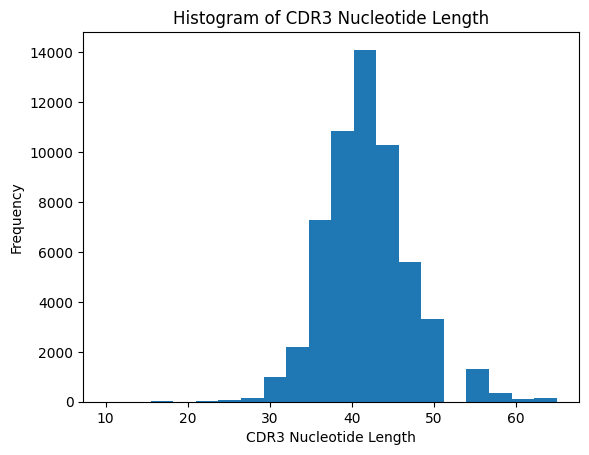

In [30]:
x_lim = (10, 65)  # Set the lower and upper limits of the x-axis
num_bins =20  # Set the number of bins for the histogram

# Create the histogram plot with customized x-axis limits and bins
plt.hist(tenx_data['cdr3_nt_len'], bins=num_bins, range=x_lim)

# Label the axes and add a title
plt.xlabel('CDR3 Nucleotide Length')
plt.ylabel('Frequency')
plt.title('Histogram of CDR3 Nucleotide Length')

# Show the plot
plt.show()

In [31]:
list(adap_data.columns)

['sample_name',
 'species',
 'locus',
 'product_subtype',
 'kit_pool',
 'sku',
 'test_name',
 'sample_catalog_tags',
 'sample_rich_tags',
 'sample_rich_tags_json',
 'hla_class_i',
 'hla_class_ii',
 'kit_control',
 'total_templates',
 'productive_templates',
 'outofframe_templates',
 'stop_templates',
 'dj_templates',
 'total_rearrangements',
 'productive_rearrangements',
 'outofframe_rearrangements',
 'stop_rearrangements',
 'dj_rearrangements',
 'total_reads',
 'total_productive_reads',
 'total_outofframe_reads',
 'total_stop_reads',
 'total_dj_reads',
 'productive_simpson_clonality',
 'productive_clonality',
 'productive_entropy',
 'sample_simpson_clonality',
 'sample_clonality',
 'sample_entropy',
 'sample_amount_ng',
 'sample_cells_mass_estimate',
 'fraction_productive_of_cells_mass_estimate',
 'sample_cells',
 'fraction_productive_of_cells',
 'max_productive_frequency',
 'max_frequency',
 'counting_method',
 'primer_set',
 'sequence_result_status',
 'release_date',
 'upload_date',

In [32]:
adap_data['rearrangement']

0          CGCACAGAGCAGCGGGACTCAGCCATGTATCGCTGTGCTAGCAGCT...
1          TCAGCGCACAGAGCAGCGGGACTCAGCCATGTATCGCTGTGCTAGC...
2          ACGATTCAGCGCACAGAGCAGCGGGACTCAGCCATGTATCGCTGTG...
3          ACGATTCAGCGCACAGAGCAGCGGGACTCAGCCATGTATCGCTGTG...
4          CAGCGCACAGAGCAGCGGGACTCAGCCATGTATCGCTGTGCTAGCA...
                                 ...                        
3503846    CTCTGACAGTGACCAGTGCCCATCCTGAAGACAGCAGCTTCTACAT...
3503847    NNNNTGTCGGCTGCTCCCTCCCAGACATCTGTGTACTTCTGTGCCA...
3503848    ACAGTGACCAGTGCCCATCCTGAAGACAGCAGCTTCTACATCTGCA...
3503849    CAGCCCTCAGAACCCAGGGACTCAGCTGTGTACTTCTGTGCCAGCA...
3503850    NTGTCGGCTGCTCCCTCCCAAACATCTGTGTACTTCTGTGCCAGCA...
Name: rearrangement, Length: 3503851, dtype: object

In [33]:
adap_data['cdr3_nt_len'] = adap_data['rearrangement'].apply(lambda x: len(str(x)))

In [34]:
adap_data['cdr3_nt_len']

0          87
1          87
2          87
3          87
4          87
           ..
3503846    87
3503847    87
3503848    87
3503849    87
3503850    87
Name: cdr3_nt_len, Length: 3503851, dtype: int64

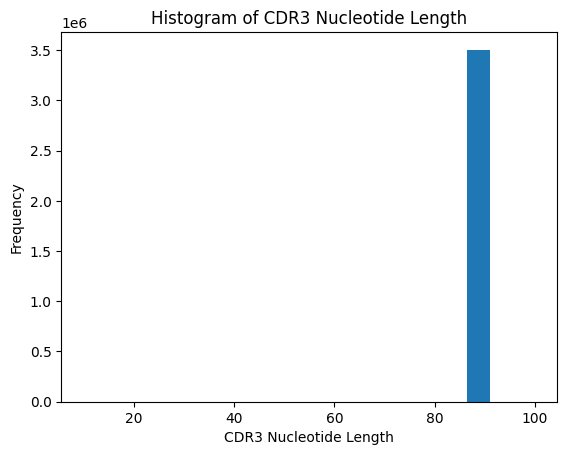

In [35]:
x_lim = (10, 100)  # Set the lower and upper limits of the x-axis
num_bins =20  # Set the number of bins for the histogram

# Create the histogram plot with customized x-axis limits and bins
plt.hist(adap_data['cdr3_nt_len'], bins=num_bins, range=x_lim)

# Label the axes and add a title
plt.xlabel('CDR3 Nucleotide Length')
plt.ylabel('Frequency')
plt.title('Histogram of CDR3 Nucleotide Length')

# Show the plot
plt.show()

In [36]:
tenx_data['SampleID_barcode'] = tenx_data['SampleID']+tenx_data['barcode']

In [37]:
tenx_data['SampleID_barcode']

0        RH01AAACCTGGTTCACCTC-1
1        RH01AAACCTGGTTCACCTC-1
2        RH01AAACCTGGTTCAGTAC-1
3        RH01AAACCTGGTTCAGTAC-1
4        RH01AAACCTGTCGTTTAGG-1
                  ...          
56763    UA37TTTGCGCAGCCCAATT-1
56764    UA37TTTGGTTGTCTGCGGT-1
56765    UA37TTTGGTTGTCTGCGGT-1
56766    UA37TTTGTCACATTGCGGC-1
56767    UA37TTTGTCACATTGCGGC-1
Name: SampleID_barcode, Length: 56768, dtype: object

In [38]:
tenx_data

,barcode,is_cell,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,...,fwr2_nt,cdr2,cdr2_nt,fwr3,fwr3_nt,fwr4,fwr4_nt,exact_subclonotype_id,cdr3_nt_len,SampleID_barcode
0,AAACCTGGTTCACCTC-1,True,AAACCTGGTTCACCTC-1_contig_1,True,465,TRA,TRAV13-1,NaN,TRAJ13,TRAC,...,TTCCCTTGGTATAAGCAAGAACTTGGAAAAAGACCTCAGCTTATTA...,IRSNVGE,ATTCGTTCAAATGTGGGCGAA,KKDQRIAVTLNKTAKHFSLHITETQPEDSAVYF,AAGAAAGACCAACGAATTGCTGTTACATTGAACAAGACAGCCAAAC...,GTGTKLQVIP,GGAACTGGAACAAAGCTCCAAGTCATCCCAA,1.0,45,RH01AAACCTGGTTCACCTC-1
1,AAACCTGGTTCACCTC-1,True,AAACCTGGTTCACCTC-1_contig_2,True,512,TRB,TRBV6-1,TRBD1,TRBJ1-2,TRBC1,...,ATGTACTGGTATCGACAAGACCCAGGCATGGGACTGAGGCTGATTT...,SASEGT,TCAGCTTCTGAGGGTACC,TDKGEVPNGYNVSRLNKREFSLRLESAAPSQTSVYF,ACTGACAAAGGAGAAGTCCCCAATGGCTACAATGTCTCCAGATTAA...,GSGTRLTVV,GGTTCGGGGACCAGGTTAACCGTTGTAG,1.0,48,RH01AAACCTGGTTCACCTC-1
2,AAACCTGGTTCAGTAC-1,True,AAACCTGGTTCAGTAC-1_contig_1,True,475,TRA,TRAV10,NaN,TRAJ20,TRAC,...,TTAAGGTGGTATAAGCAAGATACTGGGAGAGGTCCTGTTTCCCTGA...,MTFSENT,ATGACTTTCAGTGAGAACACA,KSNGRYTATLDADTKQSSLHITASQLSDSASYI,AAGTCGAACGGAAGATATACAGCAACTCTGGATGCAGACACAAAGC...,GAGTTVTVRA,GGAGCCGGAACCACAGTAACTGTAAGAGCAA,1.0,36,RH01AAACCTGGTTCAGTAC-1
3,AAACCTGGTTCAGTAC-1,True,AAACCTGGTTCAGTAC-1_contig_2,True,499,TRB,TRBV3-1,NaN,TRBJ2-7,TRBC2,...,ATGTATTGGTATAAACAGGACTCTAAGAAATTTCTGAAGATAATGT...,YNNKEL,TACAATAATAAGGAGCTC,IINETVPNRFSPKSPDKAHLNLHINSLELGDSAVYF,ATTATAAATGAAACAGTTCCAAATCGCTTCTCACCTAAATCTCCAG...,GPGTRLTVT,GGGCCGGGCACCAGGCTCACGGTCACAG,1.0,45,RH01AAACCTGGTTCAGTAC-1
4,AAACCTGTCGTTTAGG-1,True,AAACCTGTCGTTTAGG-1_contig_1,True,518,TRB,TRBV6-1,TRBD1,TRBJ1-1,TRBC1,...,ATGTACTGGTATCGACAAGACCCAGGCATGGGACTGAGGCTGATTT...,SASEGT,TCAGCTTCTGAGGGTACC,TDKGEVPNGYNVSRLNKREFSLRLESAAPSQTSVYF,ACTGACAAAGGAGAAGTCCCCAATGGCTACAATGTCTCCAGATTAA...,GQGTRLTVV,GGACAAGGCACCAGACTCACAGTTGTAG,1.0,54,RH01AAACCTGTCGTTTAGG-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56763,TTTGCGCAGCCCAATT-1,True,TTTGCGCAGCCCAATT-1_contig_2,True,653,TRB,TRBV5-4,NaN,TRBJ2-6,TRBC2,...,GTGTCCTGGTACCAACAGGCCCTGGGTCAGGGGCCCCAGTTTATCT...,YYREEE,TATTATAGGGAGGAAGAG,NGRGNFPPRFSGLQFPNYSSELNVNALELDDSALYL,AATGGCAGAGGAAACTTCCCTCCTAGATTCTCAGGTCTCCAGTTCC...,GAGSRLTVL,GGGGCCGGCAGCAGGCTGACCGTGCTGG,1.0,45,UA37TTTGCGCAGCCCAATT-1
56764,TTTGGTTGTCTGCGGT-1,True,TTTGGTTGTCTGCGGT-1_contig_1,True,504,TRA,TRAV26-1,NaN,TRAJ28,TRAC,...,GTGTATTGGTATCGACAGATTCACTCCCAGGGGCCACAGTATATCA...,GLKNN,GGTCTAAAAAACAAT,ETNEMASLIITEDRKSSTLILPHATLRDTAVYY,GAAACCAATGAAATGGCCTCTCTGATCATCACAGAAGACAGAAAGT...,GKGTKLSVIP,GGGAAGGGGACCAAACTCTCGGTCATACCAA,1.0,39,UA37TTTGGTTGTCTGCGGT-1
56765,TTTGGTTGTCTGCGGT-1,True,TTTGGTTGTCTGCGGT-1_contig_2,True,470,TRB,TRBV29-1,NaN,TRBJ1-2,TRBC1,...,ATGTTCTGGTACCGTCAGCAACCTGGACAGAGCCTGACACTGATCG...,ANQGSEA,GCAAATCAGGGCTCTGAGGCC,TYESGFVIDKFPISRPNLTFSTLTVSNMSPEDSSIYL,ACATATGAGAGTGGATTTGTCATTGACAAGTTTCCCATCAGCCGCC...,GSGTRLTVV,GGTTCGGGGACCAGGTTAACCGTTGTAG,1.0,33,UA37TTTGGTTGTCTGCGGT-1
56766,TTTGTCACATTGCGGC-1,True,TTTGTCACATTGCGGC-1_contig_1,True,688,TRA,TRAV8-3,NaN,TRAJ6,TRAC,...,CTCTTCTGGTATGTCCAGTCCCCCGGCCAAGGCCTCCAGCTGCTCC...,YFSGDTLV,TACTTTTCAGGAGACACTCTGGTT,QGIKGFEAEFKRSQSSFNLRKPSVHWSDAAEYF,CAAGGCATTAAAGGCTTTGAGGCTGAATTTAAGAGGAGTCAATCTT...,GRGTSLIVHP,GGAAGAGGAACCAGCCTTATTGTTCATCCGT,1.0,42,UA37TTTGTCACATTGCGGC-1


In [39]:
# for 10x barcode id +sample ID

In [40]:
if os.path.exists(TCR_SEL_ALL_PATH):
    tcr_sel_all = pd.read_csv(TCR_SEL_ALL_PATH)
else:
    tcr_sel_all = pd.DataFrame()
    for patient in shared_patients:
        patient_tenx = tenx_data[tenx_data['PatientID']== patient]
        patient_adap = adap_data[adap_data['patientID']== patient]
        tcr_data = treatcr(patient_tenx)
        hvg_data = treathvg(patient_adap)
        # unique hvg data
        hvg_data = hvg_data.drop_duplicates()
        tcr_sel = link(tcr_data, hvg_data, 2)
        tcr_sel['patient']= np.repeat(patient,tcr_sel.shape[0])
        print(patient)
        tcr_sel_all = pd.concat([tcr_sel_all,tcr_sel])
        tcr_sel.sort_values('#clones')
        plt.hist(tcr_sel['#clones'], bins= 40)
        plt.xlabel('#clones')
        plt.ylabel('Counts')
        plt.title(patient)
        plt.show()
    tcr_sel_all.to_csv(TCR_SEL_ALL_PATH, index=False)